# Conditional 3D prediction

Generate a categorical `64³` volume whose selected XY slice resembles the condition image without copying it, while XY/XZ/YZ retain the same morphology and remain continuous beyond ±3 slices.

In [1]:
from argparse import Namespace
from pathlib import Path
import sys
import time

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.app.api import AnchorSlice, PredictOptions
from src.app.runtime import build_dataset, build_loader, load_defaults, load_predictor
from src.modeling.phases import quantize_phase

## Parameters

The predictor trains a shared 3D SliceGAN field, adds a small categorical VAE/diffusion reference bank, aligns its spatial noise to the anchor, then fine-tunes only until the anchor is similar. Candidate checkpoints are selected by 2D morphology and slice-continuity scores. On an RTX 2060, expect roughly 12–15 minutes.

In [2]:
RUN_DIR = "run/20260712-163751-714469"
ANCHOR_IMAGE_COUNT = 1

options_kwargs = dict(
    slicegan_steps=5000,
    slicegan_hybrid_steps=1000,
    slicegan_condition_steps=800,
    slicegan_finetune_steps=500,
)

## Predict

In [3]:
run_dir = ROOT / RUN_DIR
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
args = Namespace(**load_defaults(run_dir / "vae.yaml"))
args.data_dir = ROOT / args.data_dir
args.batch_size = ANCHOR_IMAGE_COUNT

batch = next(build_loader(build_dataset(args), args, device=torch.device("cpu")))
anchor_image = quantize_phase(batch[0, 0], args.num_phases).numpy()
anchor = AnchorSlice(
    image=anchor_image,
    axis=0,
    index=anchor_image.shape[0] // 2,
)
options = PredictOptions(num_phases=args.num_phases, **options_kwargs)

predictor = load_predictor(run_dir, device=device)
start_time = time.perf_counter()
volume, stats = predictor.predict(options, anchors=[anchor])
elapsed_seconds = time.perf_counter() - start_time
volume_np = volume.cpu().numpy()

print("device:", device)
print(f"elapsed: {elapsed_seconds:.1f} seconds")
print("volume:", volume_np.shape, volume.dtype)
print("selected training step:", int(stats["slicegan_selected_step"]))
print("condition candidates checked:", int(stats["slicegan_condition_candidates"]))
print(f"anchor mismatch: {float(stats['slicegan_anchor_mismatch']):.2%}")
print("phase fraction:", np.round(stats["slicegan_phase_fraction"].cpu().numpy(), 4).tolist())

device: cuda
elapsed: 759.0 seconds
volume: (64, 64, 64) torch.uint8
selected training step: 5500
condition candidates checked: 3
anchor mismatch: 7.96%
phase fraction: [0.2603999972343445, 0.12540000677108765, 0.6141999959945679]


## Quality check

The center must resemble—but not equal—the condition. The local boundary profile should not spike just outside ±3.

anchor mismatch: 7.96%
target phase fraction: [0.2578, 0.127, 0.6152]
volume phase fraction: [0.2604, 0.1254, 0.6142]
axis transition rate: [0.2, 0.2104, 0.2019]
anchor ±6 boundary profile: [0.1836, 0.1829, 0.1943, 0.1929, 0.2185, 0.2249, 0.2485, 0.1787, 0.1814, 0.2195, 0.1826, 0.1604]
largest local boundary jump: 0.0698


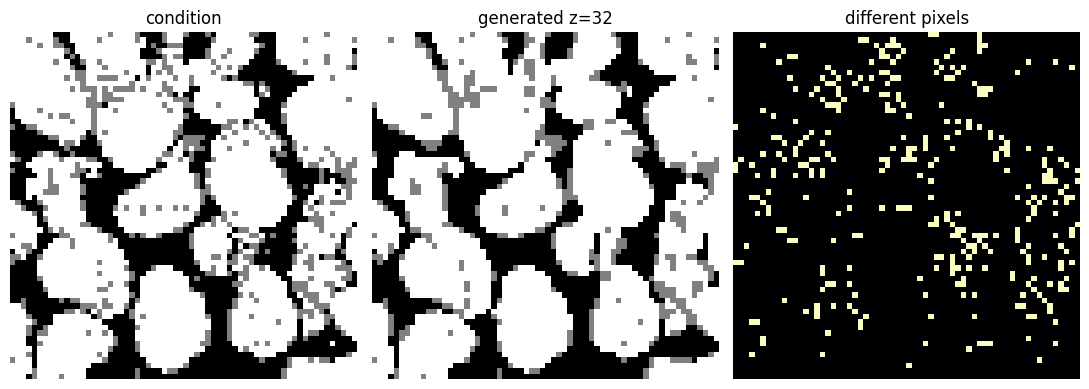

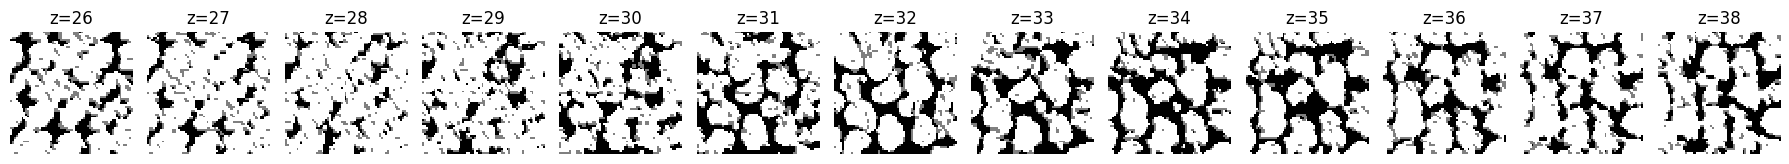

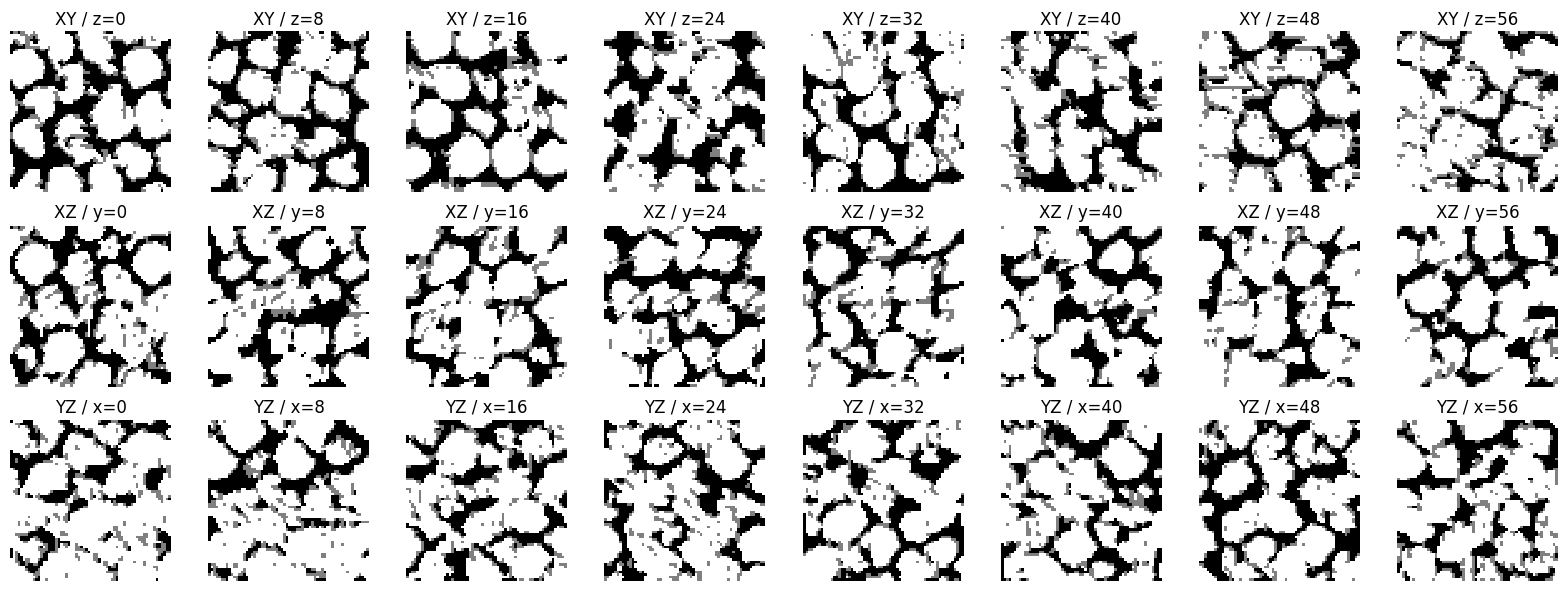

In [4]:
center = volume_np[anchor.index]
difference = center != anchor_image
anchor_mismatch = np.mean(difference)
target_phase_fraction = [
    np.mean(anchor_image == phase) for phase in range(args.num_phases)
]
volume_phase_fraction = [
    np.mean(volume_np == phase) for phase in range(args.num_phases)
]
axis_transition_rate = [
    np.mean(np.diff(volume_np, axis=axis) != 0) for axis in range(3)
]
z_boundaries = np.mean(volume_np[1:] != volume_np[:-1], axis=(1, 2))
local_boundaries = z_boundaries[anchor.index - 6 : anchor.index + 6]
local_boundary_jump = np.max(np.abs(np.diff(local_boundaries)))

print(f"anchor mismatch: {anchor_mismatch:.2%}")
print("target phase fraction:", np.round(target_phase_fraction, 4).tolist())
print("volume phase fraction:", np.round(volume_phase_fraction, 4).tolist())
print("axis transition rate:", np.round(axis_transition_rate, 4).tolist())
print("anchor ±6 boundary profile:", np.round(local_boundaries, 4).tolist())
print(f"largest local boundary jump: {local_boundary_jump:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
plots = [
    (anchor_image, "condition", "gray", 0, args.num_phases - 1),
    (center, "generated z=32", "gray", 0, args.num_phases - 1),
    (difference, "different pixels", "magma", 0, 1),
]
for axis, (image, title, cmap, vmin, vmax) in zip(axes, plots):
    axis.imshow(image, cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest")
    axis.set_title(title)
    axis.axis("off")
plt.tight_layout()

offsets = range(-6, 7)
fig, axes = plt.subplots(1, len(offsets), figsize=(18, 2.4))
for axis, offset in zip(axes, offsets):
    index = anchor.index + offset
    axis.imshow(
        volume_np[index],
        cmap="gray",
        vmin=0,
        vmax=args.num_phases - 1,
        interpolation="nearest",
    )
    axis.set_title(f"z={index}")
    axis.axis("off")
plt.tight_layout()

indices = range(0, volume_np.shape[0], 8)
slice_getters = [
    (lambda index: volume_np[index], "XY / z"),
    (lambda index: volume_np[:, index, :], "XZ / y"),
    (lambda index: volume_np[:, :, index], "YZ / x"),
]
fig, axes = plt.subplots(3, len(indices), figsize=(16, 6))
for row, (get_slice, axis_name) in enumerate(slice_getters):
    for column, index in enumerate(indices):
        axes[row, column].imshow(
            get_slice(index),
            cmap="gray",
            vmin=0,
            vmax=args.num_phases - 1,
            interpolation="nearest",
        )
        axes[row, column].set_title(f"{axis_name}={index}")
        axes[row, column].axis("off")
plt.tight_layout()

## 3D slice browser

Choose a plane and move the slider to inspect every slice.

In [5]:
plane_selector = widgets.ToggleButtons(
    options=[("XY", 0), ("XZ", 1), ("YZ", 2)],
    value=0,
    description="plane",
)
index_slider = widgets.IntSlider(
    value=volume_np.shape[0] // 2,
    min=0,
    max=volume_np.shape[0] - 1,
    step=1,
    description="index",
    continuous_update=False,
)

def show_slice(plane, index):
    if plane == 0:
        image = volume_np[index]
    elif plane == 1:
        image = volume_np[:, index, :]
    else:
        image = volume_np[:, :, index]

    plt.figure(figsize=(5, 5))
    plt.imshow(
        image,
        cmap="gray",
        vmin=0,
        vmax=args.num_phases - 1,
        interpolation="nearest",
    )
    plt.title(f"{('XY', 'XZ', 'YZ')[plane]} plane · index {index}")
    plt.axis("off")
    plt.show()

slice_output = widgets.interactive_output(
    show_slice,
    {"plane": plane_selector, "index": index_slider},
)
display(widgets.HBox([plane_selector, index_slider]), slice_output)

Output()